# Goal Type x Agent x Focus

Import Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import Table

import seaborn as sns

## Combined Subgroup:

1. Contigency Table
2. Proportions
3. Chi-Square Test
4. Expected Counts
5. Cramér's V
6. Standardized Residuals
7. Interpretation

Read data

In [22]:
subgroup_theoretical = pd.read_csv("../../data/processed/subgroup_theoretical.csv")

In [23]:
subgroup_theoretical= subgroup_theoretical[subgroup_theoretical["Response_Full"]!= "missing_response"].copy()

1. Contingency Table

In [24]:
contingency = pd.crosstab(
    [subgroup_theoretical["Goal_Type"], subgroup_theoretical["Agent"], subgroup_theoretical["Focus"]],
    subgroup_theoretical["Response_Full"]
)

contingency

Response_Full                  L1_transfer  L2_other  correct
Goal_Type         Agent Focus                                
goal_frequent     0     I                6         8        9
                        They             7         6        5
                  1     I                7         2        7
                        They             5         0        3
goal_non_frequent 0     I                7         8        9
                        They            14         1        3
                  1     I               11         1        4
                        They             5         0        3
no_goal           0     I               13         3        6
                        They            10         5        3
                  1     I                9         2        5
                        They             2         2        4

2. Proportions

In [25]:
proportions = pd.crosstab(
    [subgroup_theoretical["Goal_Type"], subgroup_theoretical["Agent"], subgroup_theoretical["Focus"]],
    subgroup_theoretical["Response_Full"],
    normalize="index"
)

proportions

Response_Full                  L1_transfer  L2_other   correct
Goal_Type         Agent Focus                                 
goal_frequent     0     I         0.260870  0.347826  0.391304
                        They      0.388889  0.333333  0.277778
                  1     I         0.437500  0.125000  0.437500
                        They      0.625000  0.000000  0.375000
goal_non_frequent 0     I         0.291667  0.333333  0.375000
                        They      0.777778  0.055556  0.166667
                  1     I         0.687500  0.062500  0.250000
                        They      0.625000  0.000000  0.375000
no_goal           0     I         0.590909  0.136364  0.272727
                        They      0.555556  0.277778  0.166667
                  1     I         0.562500  0.125000  0.312500
                        They      0.250000  0.250000  0.500000

3. Chi-Square Test

In [26]:
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square: 32.111
p-value: 0.0755
Degrees of freedom: 22


Even if chi-sq points to being close to reaching significance, there aren't enough observations for this test when they are meant to be distributed into so many conditions. 

4. Expected Counts

In [27]:
expected_df = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

expected_df

Response_Full                  L1_transfer  L2_other   correct
Goal_Type         Agent Focus                                 
goal_frequent     0     I        11.323077  4.482051  7.194872
                        They      8.861538  3.507692  5.630769
                  1     I         7.876923  3.117949  5.005128
                        They      3.938462  1.558974  2.502564
goal_non_frequent 0     I        11.815385  4.676923  7.507692
                        They      8.861538  3.507692  5.630769
                  1     I         7.876923  3.117949  5.005128
                        They      3.938462  1.558974  2.502564
no_goal           0     I        10.830769  4.287179  6.882051
                        They      8.861538  3.507692  5.630769
                  1     I         7.876923  3.117949  5.005128
                        They      3.938462  1.558974  2.502564

In [28]:
print(expected_df < 5)

Response_Full                  L1_transfer  L2_other  correct
Goal_Type         Agent Focus                                
goal_frequent     0     I            False      True    False
                        They         False      True    False
                  1     I            False      True    False
                        They          True      True     True
goal_non_frequent 0     I            False      True    False
                        They         False      True    False
                  1     I            False      True    False
                        They          True      True     True
no_goal           0     I            False      True    False
                        They         False      True    False
                  1     I            False      True    False
                        They          True      True     True


There just aren't enough observations for a table that is dividing them into 3 goal type conditions, 2 agency conditions, 2 focus conditions and 3 response categories.

5. Cramér's V

In [29]:
n = contingency.values.sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(contingency.shape) - 1))
)

print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.287


V = : 0.287. The effect size is also good -but the same criteria applies here. Not enough observations. 

6. Standardized Residuals

In [30]:
residuals = (
    contingency - expected
) / np.sqrt(expected)

residuals

Response_Full                  L1_transfer  L2_other   correct
Goal_Type         Agent Focus                                 
goal_frequent     0     I        -1.581905  1.661694  0.672971
                        They     -0.625342  1.330733 -0.265819
                  1     I        -0.312452 -0.633122  0.891677
                        They      0.534900 -1.248589  0.314445
goal_non_frequent 0     I        -1.400900  1.536598  0.544634
                        They      1.726150 -1.338947 -1.108661
                  1     I         1.112767 -1.199447 -0.449277
                        They      0.534900 -1.248589  0.314445
no_goal           0     I         0.659138 -0.621661 -0.336229
                        They      0.382440  0.796797 -1.108661
                  1     I         0.400158 -0.633122 -0.002292
                        They     -0.976774  0.353219  0.946576

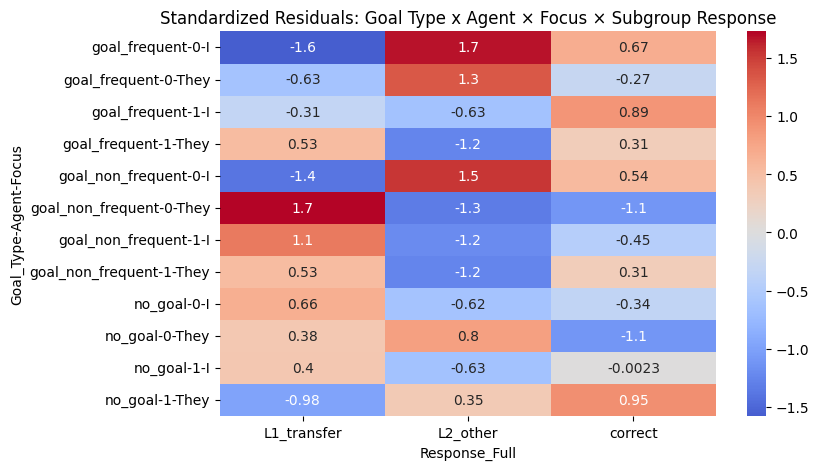

In [31]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Goal Type x Agent × Focus × Subgroup Response")
plt.show()

7. Interpretation

This residual map still has structure and it points at the expected directions even if nothing exceeds +-2:

- Frequent goal: 
    -   Agent = 0 + Focus = 1: participants aren't transfering, they are siding for an L2-other options, a tendency that we had already observed.

    - Agent = 1 + Focus = 1: correct = +0.89, not by far, but more correct answers than the expected. 

- Non-frequent goal: 
    - Agent = O + Focus = They: this seems to be where the task becomes the hardest with the highest transfer, the lowest L2-other and also one of the lowest correct responses. This could be related to lack of embodying apart from the goal.

    - Agent = 1 + Focus = I: L1 = +1.11 and L2 = -1.20. Embodying explicit agency for this type of goal makes participants leave the L2 route but does not produce correctness, they fall back to transfer. It is interesting for this condition to show this pattern: embodying liability seems hard.

- No goal: 
    - Agent = 1 + Focus = They: correct = + 0.95 compared to the other 3 no goal conditions, coherent with what was observed in EDA.

Once the no goal variability is removed, even though there still won't be enough observations, we should have a clearer or sharpened picture of what is going on. 

## Combined Subgroup:
### Goals

1. Contigency Table
2. Proportions
3. Chi-Square Test
4. Expected Counts
5. Cramér's V
6. Standardized Residuals
7. Interpretation

Split data into goals and no_goals

In [32]:
goals = subgroup_theoretical[subgroup_theoretical["Goal_Type"]!= "no_goal"].copy()

1. Contingency Table

In [33]:
goal_contingency = pd.crosstab(
    [goals["Goal_Type"], goals["Agent"], goals["Focus"]],
    goals["Response_Full"]
)

goal_contingency

Response_Full                  L1_transfer  L2_other  correct
Goal_Type         Agent Focus                                
goal_frequent     0     I                6         8        9
                        They             7         6        5
                  1     I                7         2        7
                        They             5         0        3
goal_non_frequent 0     I                7         8        9
                        They            14         1        3
                  1     I               11         1        4
                        They             5         0        3

2. Proportions

In [34]:
goal_proportions = pd.crosstab(
    [goals["Goal_Type"], goals["Agent"], goals["Focus"]],
    goals["Response_Full"],
    normalize="index"
)

goal_proportions

Response_Full                  L1_transfer  L2_other   correct
Goal_Type         Agent Focus                                 
goal_frequent     0     I         0.260870  0.347826  0.391304
                        They      0.388889  0.333333  0.277778
                  1     I         0.437500  0.125000  0.437500
                        They      0.625000  0.000000  0.375000
goal_non_frequent 0     I         0.291667  0.333333  0.375000
                        They      0.777778  0.055556  0.166667
                  1     I         0.687500  0.062500  0.250000
                        They      0.625000  0.000000  0.375000

3. Chi-Square Test

In [35]:
chi2, p, dof, expected = chi2_contingency(goal_contingency)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square: 26.419
p-value: 0.0229
Degrees of freedom: 14


As expected, onces removed a goal condition that behaves differently, with fewer observations, signigicance improves. 

4. Expected Counts

In [36]:
goal_expected_df = pd.DataFrame(
    expected,
    index=goal_contingency.index,
    columns=goal_contingency.columns
)

goal_expected_df

Response_Full                  L1_transfer  L2_other   correct
Goal_Type         Agent Focus                                 
goal_frequent     0     I        10.885496  4.564885  7.549618
                        They      8.519084  3.572519  5.908397
                  1     I         7.572519  3.175573  5.251908
                        They      3.786260  1.587786  2.625954
goal_non_frequent 0     I        11.358779  4.763359  7.877863
                        They      8.519084  3.572519  5.908397
                  1     I         7.572519  3.175573  5.251908
                        They      3.786260  1.587786  2.625954

In [37]:
print(goal_expected_df < 5)

Response_Full                  L1_transfer  L2_other  correct
Goal_Type         Agent Focus                                
goal_frequent     0     I            False      True    False
                        They         False      True    False
                  1     I            False      True    False
                        They          True      True     True
goal_non_frequent 0     I            False      True    False
                        They         False      True    False
                  1     I            False      True    False
                        They          True      True     True


There are  X groups with fewer than  5 observations

5. Cramér's V

In [38]:
n = goal_contingency.values.sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(goal_contingency.shape) - 1))
)

print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.318


V = 0.255: 

6. Standardized Residuals

In [39]:
goal_residuals = (
    goal_contingency - expected
) / np.sqrt(expected)

goal_residuals

Response_Full                  L1_transfer  L2_other   correct
Goal_Type         Agent Focus                                 
goal_frequent     0     I        -1.480760  1.607779  0.527861
                        They     -0.520458  1.284306 -0.373715
                  1     I        -0.208051 -0.659688  0.762791
                        They      0.623764 -1.260074  0.230824
goal_non_frequent 0     I        -1.293299  1.482989  0.399799
                        They      1.877832 -1.361041 -1.196517
                  1     I         1.245532 -1.220851 -0.546278
                        They      0.623764 -1.260074  0.230824

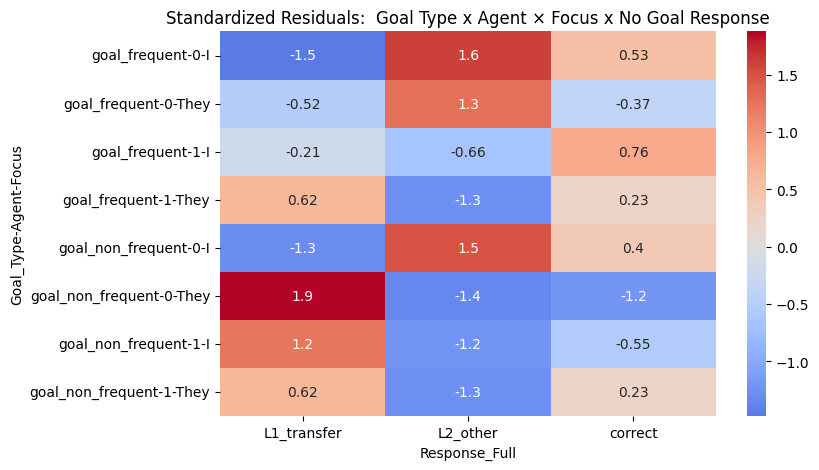

In [40]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    goal_residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals:  Goal Type x Agent × Focus x No Goal Response")
plt.show()

7. Interpretation


- From residuals:

    - Frequent goal:
        - Agency = 0 + Focus = I: what we have seen but sharpened, self-focus doesn't transfer (L1 = -1.5), it explores alternative options (L2 = + 1.6)
    - Non frequent goal:
        - Agent = 0 + Focus = They: when the protagonist is someone else and agency is implicit, participants collapse to L1 transfer (L1 = + 1.9)

- Regarding Agency:

     - When self-focus, L1 increases and L2 options decrease: accountability is cognitively expensive. Participants either produce the correct target or fall back to the L1 transfer pattern as a way to resolve. 

Goal availability determines the overall processing context. Within goal-based counterfactuals, agency and focus jointly influence how learners resolve the grammatical competition between the target construction, L1 transfer, and alternative L2 responses. Removing the no-goal condition reveals this interaction more clearly because the no-goal items rely on a partially different cognitive process, increasing heterogeneity without contributing to the hypothesised mechanism.
